In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
from sklearn import tree

In [2]:
#Reading the dataset
dataset = pd.read_csv("/content/drive/MyDrive/Copy of titanic.csv")
print("Size of dataset: ", dataset.shape)

dataset.head ()


Size of dataset:  (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
#Checking for missing values
print("Checking for missing values: \n")
dataset.isnull().sum ()

Checking for missing values: 



,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [4]:
#Filling missing Age with mean
dataset["Age"] = dataset["Age"].fillna(dataset["Age"].mean())

#Filling missing Embarked with mode
dataset["Embarked"] = dataset["Embarked"].fillna(dataset["Embarked"].mode() [0])

#Filling missing Cabin values with mode
dataset [ "Cabin"] = dataset ["Cabin"].fillna (dataset [ "Cabin"].mode() [0])
dataset ["Pclass"] = dataset ["Pclass"].apply(str)

In [5]:
# Getting dummies from all other categorial variables
for col in dataset.dtypes [dataset.dtypes == "object"].index:
  for_dummy = dataset.pop(col)
  dataset = pd.concat( [dataset, pd.get_dummies (for_dummy, prefix=col)], axis=1)
dataset.head ()

labels = dataset.pop("Survived")

In [6]:
#Splitting the dataset
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(dataset, labels, test_size=0.25)


In [11]:
from sklearn.ensemble import RandomForestClassifier

# Initialize and train the Random Forest Classifier
rf = RandomForestClassifier(n_estimators=100, random_state=42) # Using 100 estimators as suggested in the comment
rf.fit(X_train, y_train)

#By default 100 estimators are created
rf.estimators_
# No. of decision trees created: 30
y_pred = rf.predict (X_test)

In [12]:
from sklearn.metrics._plot.roc_curve import roc_curve
from sklearn.metrics import roc_auc_score, auc
false_positive_rate, true_positive_rate, thresholds = roc_curve(y_test, y_pred)
roc_auc = auc(false_positive_rate, true_positive_rate)
print("ROC AUC: ", roc_auc)

ROC AUC:  0.8275788576300086


In [13]:
n_estimators = [1, 2, 4, 8, 16, 32, 64, 100, 200]
train_results = []
test_results = []

In [14]:
for estimator in n_estimators:
  rf = RandomForestClassifier (n_estimators=estimator, n_jobs=1)
  rf.fit(X_train, y_train)
  train_pred = rf.predict (X_train)
  false_positive_rate, true_positive_rate, thresholds = roc_curve (y_train, train_pred)
  roc_auc = auc(false_positive_rate, true_positive_rate)
  train_results.append(roc_auc)
  y_pred = rf.predict (X_test)
  false_positive_rate, true_positive_rate, thresholds = roc_curve (y_test, y_pred)
  roc_auc = auc(false_positive_rate, true_positive_rate)
  test_results.append(roc_auc)


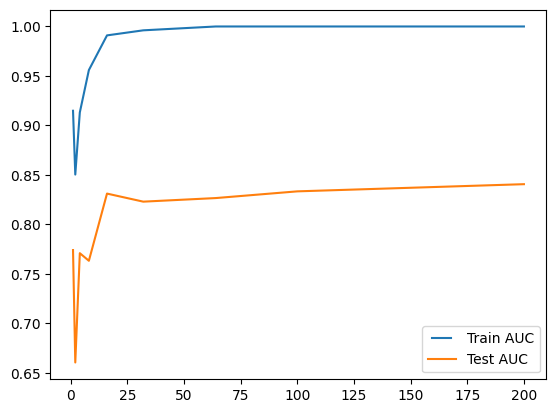

In [15]:
from matplotlib.legend_handler import HandlerLine2D
Linel, = plt.plot(n_estimators, train_results, label = "Train AUC")
Line2, = plt.plot(n_estimators, test_results, label = "Test AUC")
plt.legend(handler_map={Linel:HandlerLine2D (numpoints = 2)})
plt.ylabel = ("AUC Curve")
plt.xlabel = ("n_estimators")
plt.show()


In [16]:
#Optimized Random Forest
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier (n_estimators=30)
rf.fit (X_train, y_train)
print("No. of decision trees created: ",len (rf.estimators_))

No. of decision trees created:  30


In [17]:
#Model Evaluation
y_pred = rf.predict(X_test)
from sklearn.metrics._plot.roc_curve import roc_curve
from sklearn.metrics import roc_auc_score, auc
false_positive_rate, true_positive_rate, thresholds = roc_curve (y_test, y_pred)
roc_auc = auc (false_positive_rate, true_positive_rate)
print("ROC AUC: ", roc_auc)

ROC AUC:  0.8230605285592497


[Text(0.824390243902439, 0.9905660377358491, 'x[4] <= 52.277\ngini = 0.468\nsamples = 434\nvalue = [419.0, 249.0]'),
 Text(0.6682926829268293, 0.9716981132075472, 'x[440] <= 0.5\ngini = 0.434\nsamples = 353\nvalue = [373, 174]'),
 Text(0.7463414634146341, 0.9811320754716981, 'True  '),
 Text(0.6585365853658537, 0.9528301886792453, 'x[1727] <= 0.5\ngini = 0.431\nsamples = 352\nvalue = [373, 171]'),
 Text(0.6487804878048781, 0.9339622641509434, 'x[1059] <= 0.5\ngini = 0.429\nsamples = 350\nvalue = [373, 169]'),
 Text(0.6390243902439025, 0.9150943396226415, 'x[785] <= 0.5\ngini = 0.426\nsamples = 348\nvalue = [373, 166]'),
 Text(0.6292682926829268, 0.8962264150943396, 'x[1197] <= 0.5\ngini = 0.425\nsamples = 347\nvalue = [373, 165]'),
 Text(0.6195121951219512, 0.8773584905660378, 'x[1186] <= 0.5\ngini = 0.423\nsamples = 346\nvalue = [373, 163]'),
 Text(0.6097560975609756, 0.8584905660377359, 'x[899] <= 0.5\ngini = 0.422\nsamples = 345\nvalue = [373, 162]'),
 Text(0.47073170731707314, 0.83

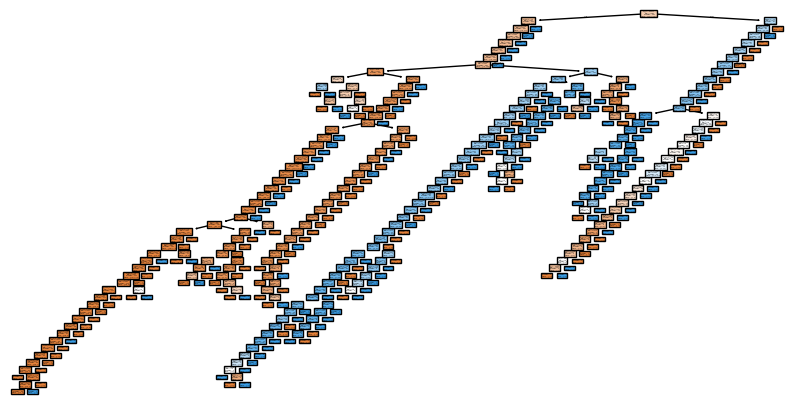

In [21]:
#Visualize the trees
plt.figure(figsize=(10,5))
tree.plot_tree(rf.estimators_[4], filled=True)
